In this series of exercises, we will venture into **using pre-trained LLMs from Hugging Face** for solving various language understanding and generation tasks. We'll start with **text classification**, more concretely **sentiment classification**.

The simplest approach offered by Hugging Face's `transformers` library to perform sequence classification tasks are **pipelines**.

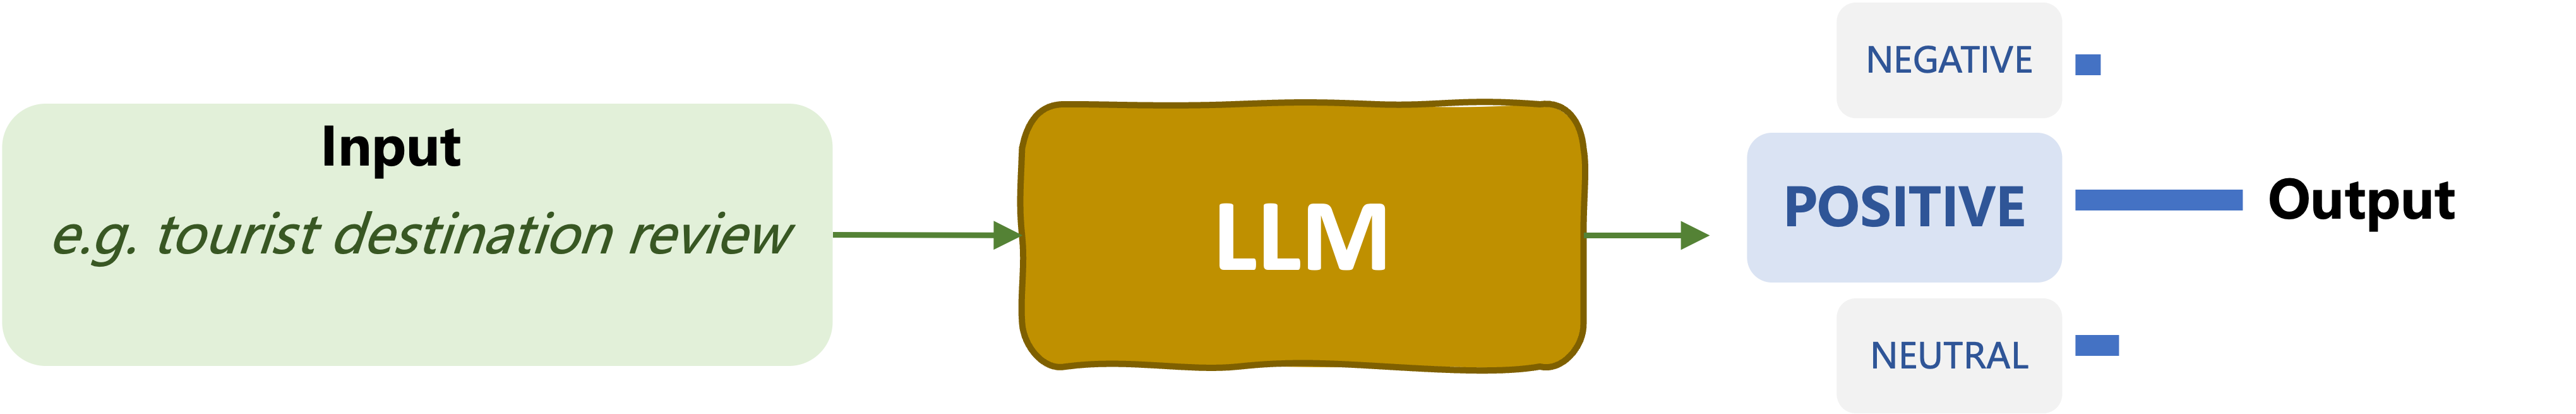

#### OPTION 1: Using a Hugging Face pipeline

In [1]:
# Start by installing Hugging Face Transformers library
!pip install transformers

We will use the following model from **Hugging Face model repository**.

**The good news**: most popular models in the repository are pretty well documented: [distilbert-base-uncased-finetuned-sst-2-english](https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english)

In [2]:
from transformers import pipeline

# Instantiate a pipeline for text classification
sentiment_classifier = pipeline("text-classification", model = "distilbert/distilbert-base-uncased-finetuned-sst-2-english")

# Input sequence: product review written by a customer
input = """Dear seller, I got very impressed with the fast
           delivery and careful packaging of my order. Great
           experience overall, thank you!"""

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [3]:
# Pass the input to the LLM pipeline to get an output
output = sentiment_classifier([input])

# Print and optionally post-process output
print(output)
print(output[0]['label'])
print(output[0]['score'])

[{'label': 'POSITIVE', 'score': 0.9998602867126465}]
POSITIVE
0.9998602867126465


That was fairly easy!

Pipelines offer the highest abstraction level for working with pre-trained LLMs, but there are alternative, more powerful approaches, such as **Auto classes**. Each one has its pros and cons. Let's analyze and compare them before trying an auto class for text classification.

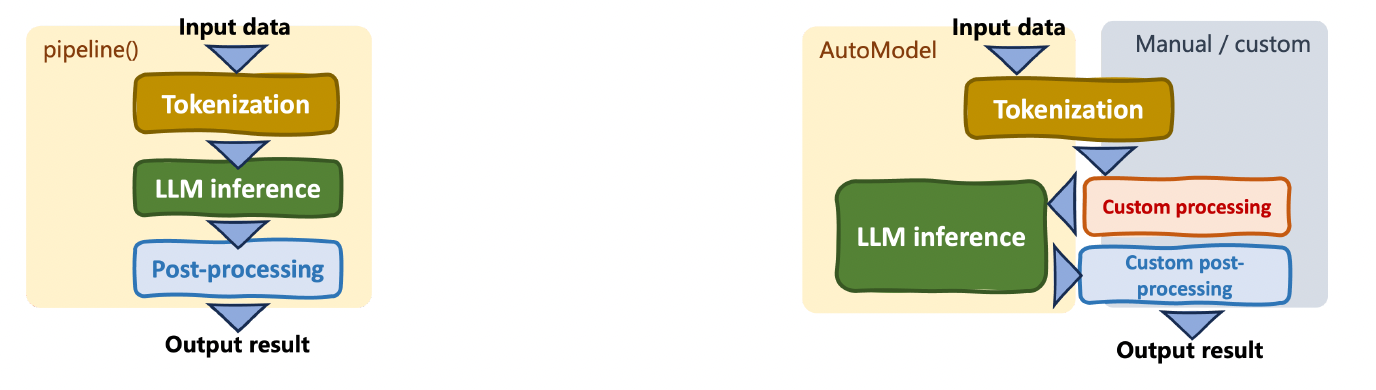

#### OPTION 2: Utilizing the `AutoModel` class for text classification

In [4]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

In [5]:
# Instantiate pre-trained LLM and its associated tokenizer
model_name = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [6]:
# Tokenize input sequence and pass it to the LLM for obtaining raw output
tokenized_seq = tokenizer(input, return_tensors="pt")
output = model(**tokenized_seq)
output

SequenceClassifierOutput(loss=None, logits=tensor([[-4.2732,  4.6030]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

In [7]:
# Extract useful classification information from raw output
logits = output.logits

prediction = torch.argmax(logits, dim=1).item()
print("Predicted class: ", prediction)

Predicted class:  1
